# IMDB Data Analysis
**Author:** Eeshan Gupta

Exploratory analysis of the ingested IMDB dataset. Covers table overviews, genre breakdowns, rating distributions, year trends, and director/actor insights.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from sqlalchemy import text

from db.session import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


def q(sql: str, **params) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, params=params)


print("Connected.")

Connected.


## 2. Table Row Counts

In [2]:
tables = [
    "title_basics", "title_ratings", "title_akas",
    "title_crew", "title_episode", "title_principals", "name_basics",
]

counts = {}
for t in tables:
    counts[t] = q(f"SELECT COUNT(*) AS n FROM {t}")["n"].iloc[0]

counts_df = pd.DataFrame.from_dict(counts, orient="index", columns=["row_count"])
counts_df["row_count"] = counts_df["row_count"].astype(int)
counts_df.sort_values("row_count", ascending=False)

,row_count
title_principals,99436957
title_akas,57069337
name_basics,15327170
title_basics,12502313
title_crew,12499798
title_episode,9654560
title_ratings,1669554


## 3. Title Type Distribution

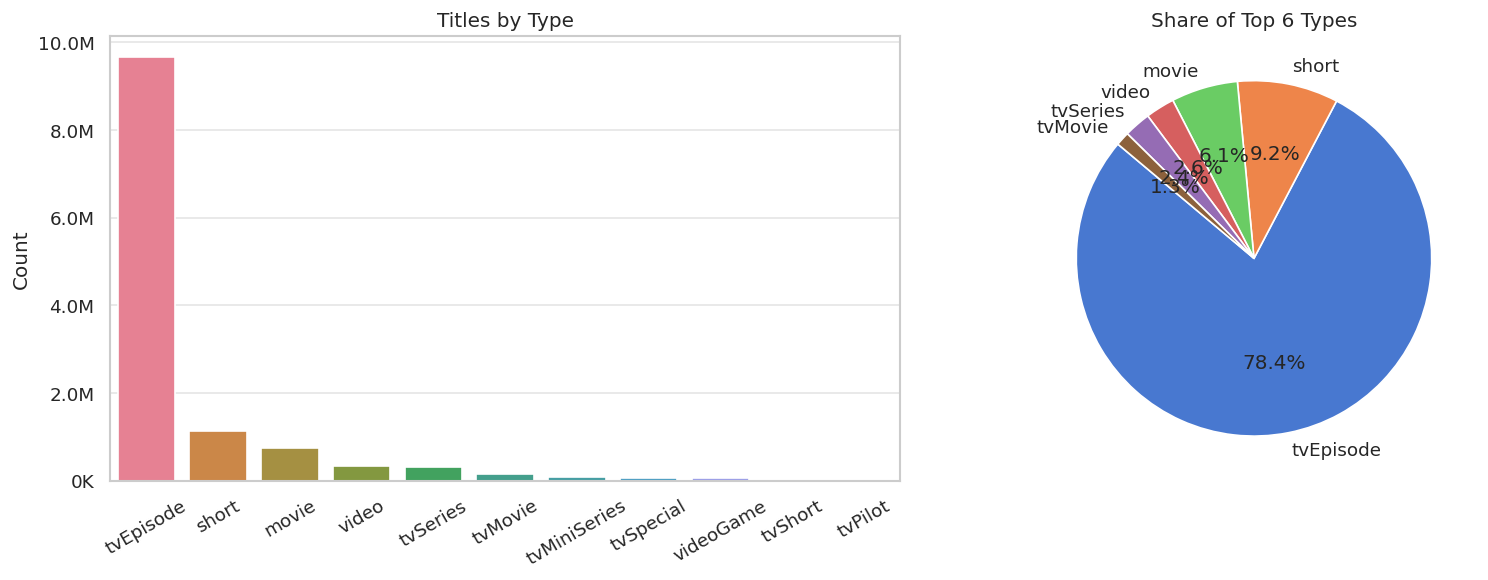

,title_type,n
0,tvEpisode,9656579
1,short,1131190
2,movie,746310
3,video,325815
4,tvSeries,299359
5,tvMovie,154876
6,tvMiniSeries,70230
7,tvSpecial,57871
8,videoGame,49091
9,tvShort,10991


In [3]:
type_counts = q("""
                SELECT title_type, COUNT(*) AS n
                FROM title_basics
                GROUP BY title_type
                ORDER BY n DESC
                """)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=type_counts, x="title_type", y="n", ax=axes[0], hue="title_type", legend=False)
axes[0].set_title("Titles by Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M" if x >= 1e6 else f"{x / 1e3:.0f}K"))

# Pie chart (top 6)
top6 = type_counts.head(6)
axes[1].pie(top6["n"], labels=top6["title_type"], autopct="%1.1f%%", startangle=140)
axes[1].set_title("Share of Top 6 Types")

plt.tight_layout()
plt.show()
type_counts

## 4. Movie Production Over Time

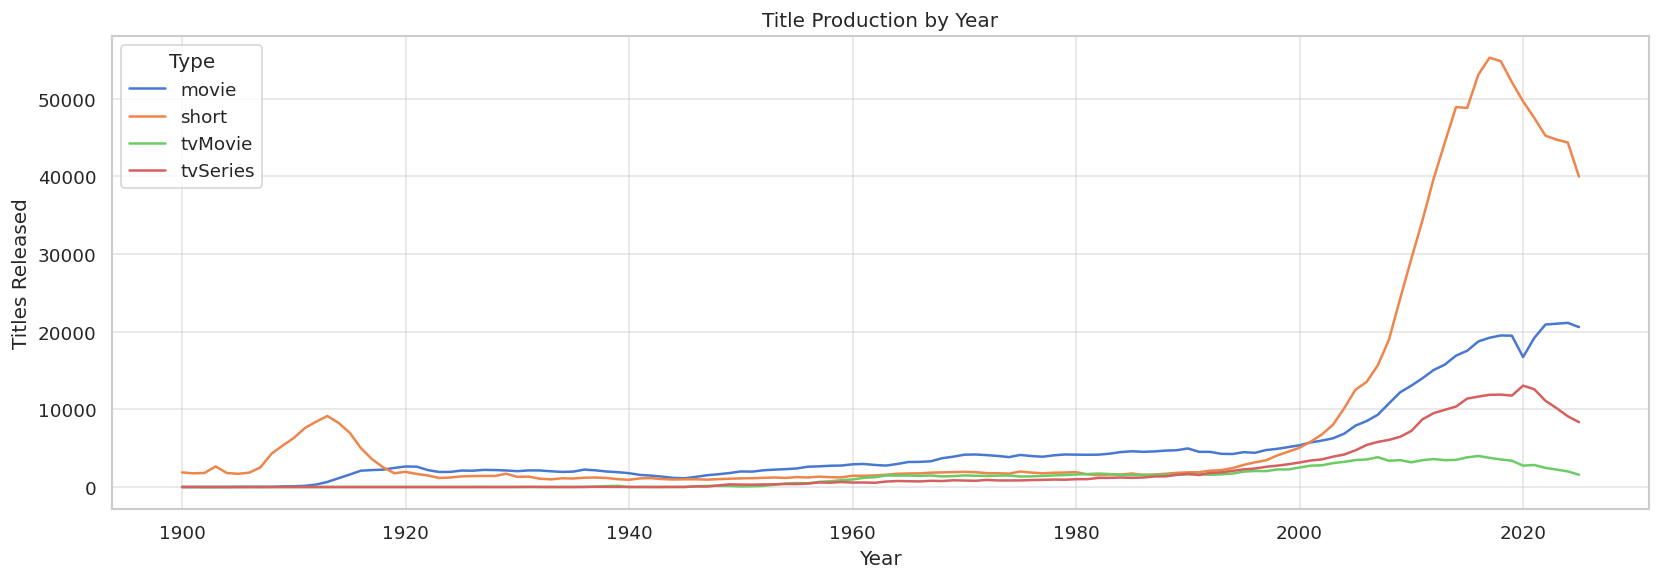

In [4]:
yearly = q("""
           SELECT start_year AS year, title_type, COUNT(*) AS n
           FROM title_basics
           WHERE start_year BETWEEN 1900 AND 2025
             AND title_type IN ('movie', 'tvSeries', 'tvMovie', 'short')
           GROUP BY start_year, title_type
           ORDER BY start_year
           """)

pivot = yearly.pivot(index="year", columns="title_type", values="n").fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(ax=ax)
ax.set_title("Title Production by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Titles Released")
ax.legend(title="Type")
plt.tight_layout()
plt.show()

## 5. Genre Analysis

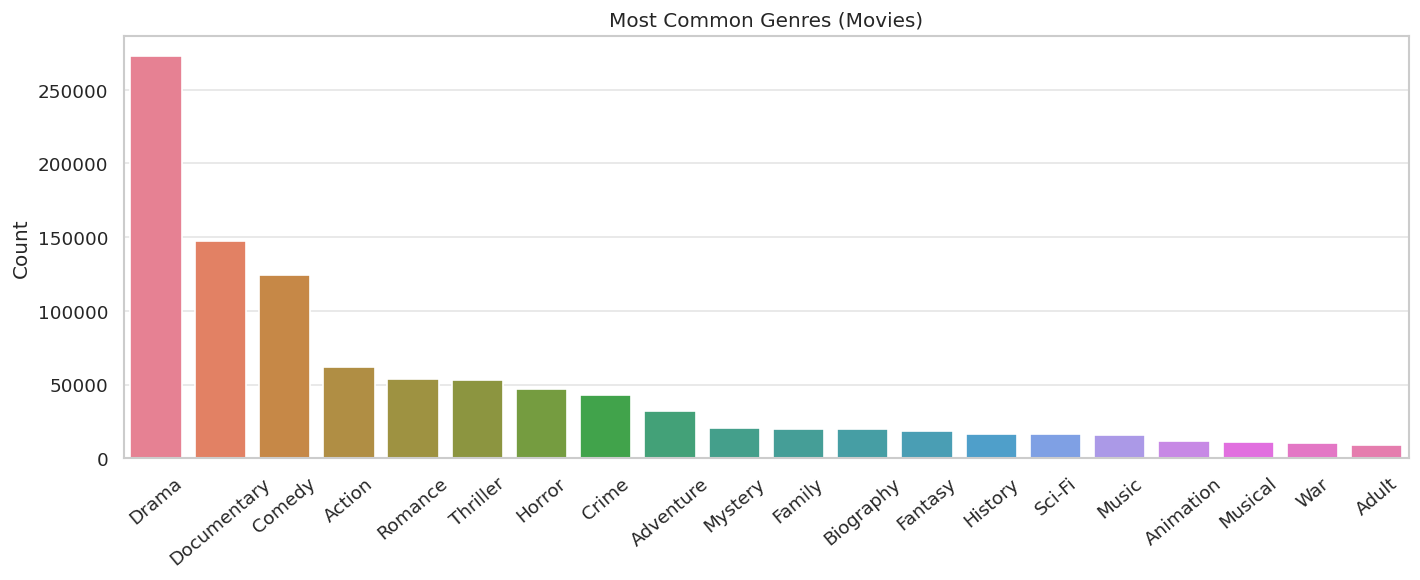

,genre,n
0,Drama,272738
1,Documentary,147683
2,Comedy,124219
3,Action,61788
4,Romance,53747
5,Thriller,53396
6,Horror,46734
7,Crime,43214
8,Adventure,31921
9,Mystery,20403


In [5]:
# Unnest the genres ARRAY to count per genre
genre_counts = q("""
                 SELECT genre, COUNT(*) AS n
                 FROM title_basics,
                      UNNEST(genres) AS genre
                 WHERE title_type = 'movie'
                 GROUP BY genre
                 ORDER BY n DESC
                 LIMIT 20
                 """)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=genre_counts, x="genre", y="n", ax=ax, hue="genre", legend=False)
ax.set_title("Most Common Genres (Movies)")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()
genre_counts

## 6. Average Rating by Genre

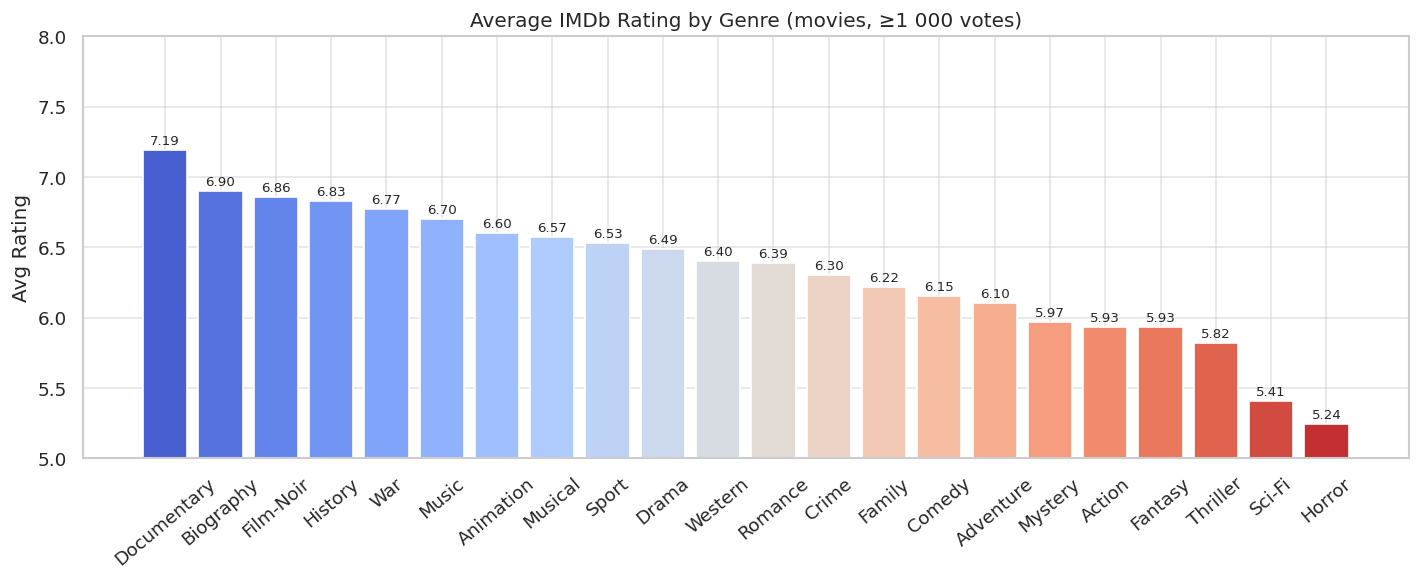

,genre,avg_rating,n_titles
0,Documentary,7.19,2526
1,Biography,6.90,2548
2,Film-Noir,6.86,459
3,History,6.83,1888
4,War,6.77,1222
5,Music,6.70,1471
6,Animation,6.60,1667
7,Musical,6.57,840
8,Sport,6.53,910
9,Drama,6.49,26904


In [6]:
genre_rating = q("""
                 SELECT genre,
                        ROUND(AVG(r.average_rating)::numeric, 2) AS avg_rating,
                        COUNT(*)                                 AS n_titles
                 FROM title_basics tb
                          JOIN title_ratings r ON tb.tconst = r.tconst,
                      UNNEST(tb.genres) AS genre
                 WHERE tb.title_type = 'movie'
                   AND r.num_votes >= 1000
                 GROUP BY genre
                 HAVING COUNT(*) >= 100
                 ORDER BY avg_rating DESC
                 """)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette("coolwarm", len(genre_rating))
bars = ax.bar(genre_rating["genre"], genre_rating["avg_rating"], color=palette)
ax.set_ylim(5, 8)
ax.set_title("Average IMDb Rating by Genre (movies, ≥1 000 votes)")
ax.set_xlabel("")
ax.set_ylabel("Avg Rating")
ax.tick_params(axis="x", rotation=40)
for bar, val in zip(bars, genre_rating["avg_rating"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{val:.2f}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
genre_rating

## 7. Rating Distribution

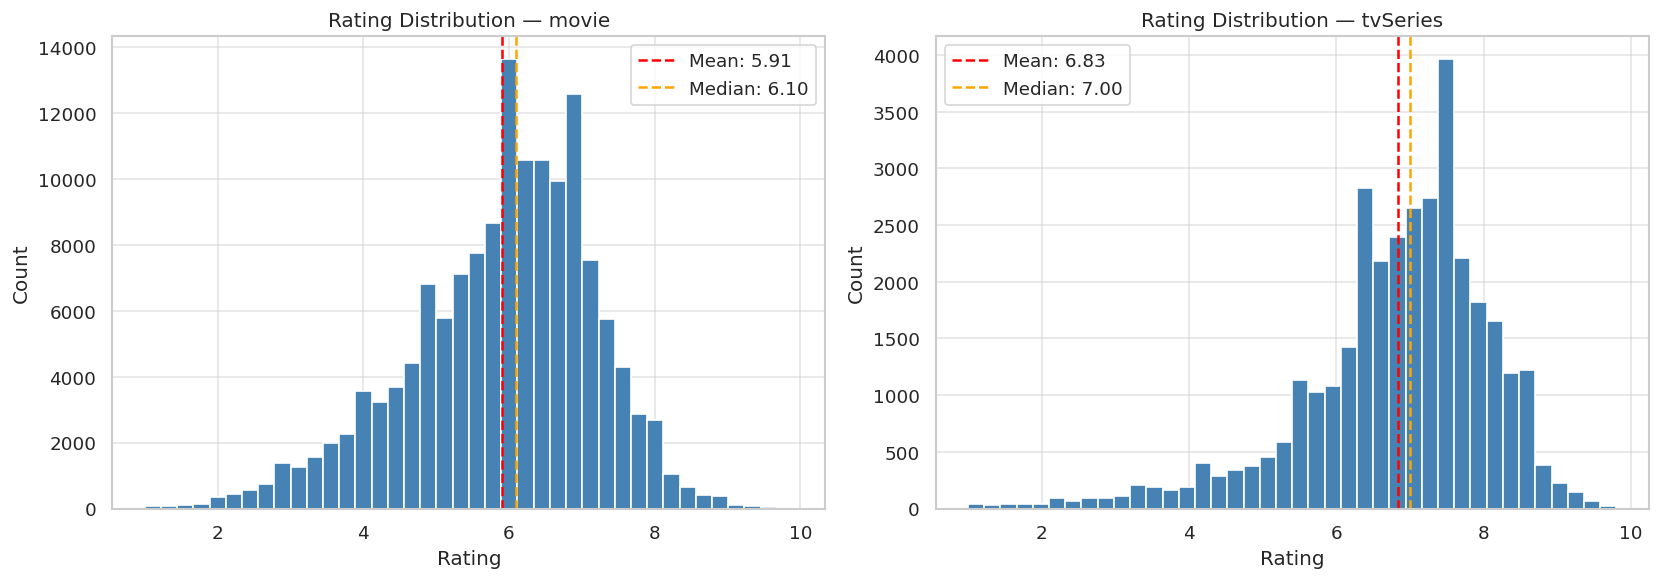

,count,mean,std,min,25%,50%,75%,max
title_type,,,,,,,,
movie,145284.0,5.91,1.28,1.0,5.2,6.1,6.8,9.9
tvSeries,34207.0,6.83,1.29,1.0,6.3,7.0,7.7,9.8


In [7]:
ratings = q("""
            SELECT r.average_rating, r.num_votes, tb.title_type
            FROM title_ratings r
                     JOIN title_basics tb ON r.tconst = tb.tconst
            WHERE r.num_votes >= 100
              AND tb.title_type IN ('movie', 'tvSeries')
            """)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title_type in zip(axes, ["movie", "tvSeries"]):
    subset = ratings[ratings["title_type"] == title_type]["average_rating"]
    ax.hist(subset, bins=40, edgecolor="white", color="steelblue")
    ax.axvline(subset.mean(), color="red", linestyle="--", label=f"Mean: {subset.mean():.2f}")
    ax.axvline(subset.median(), color="orange", linestyle="--", label=f"Median: {subset.median():.2f}")
    ax.set_title(f"Rating Distribution — {title_type}")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

ratings.groupby("title_type")["average_rating"].describe().round(2)

## 8. Votes vs Rating (scatter)

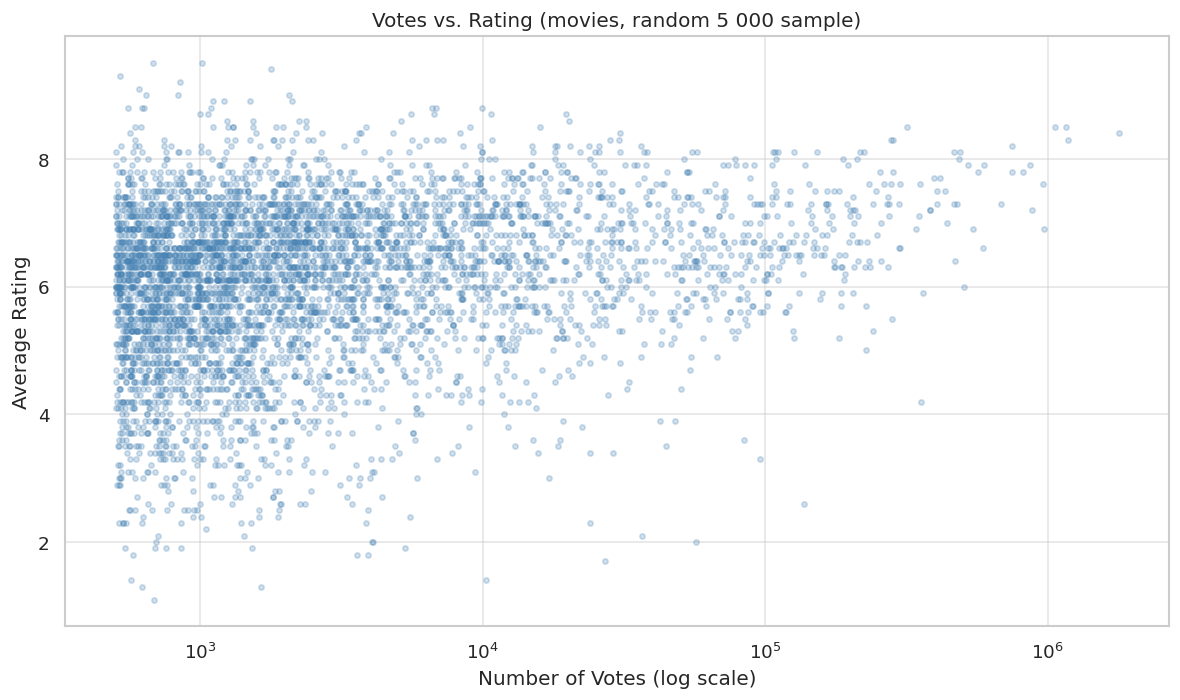

Correlation (log votes, rating): 0.227


In [8]:
scatter_df = q("""
               SELECT r.average_rating, r.num_votes
               FROM title_ratings r
                        JOIN title_basics tb ON r.tconst = tb.tconst
               WHERE tb.title_type = 'movie'
                 AND r.num_votes >= 500
               ORDER BY RANDOM()
               LIMIT 5000
               """)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_df["num_votes"], scatter_df["average_rating"],
           alpha=0.25, s=10, color="steelblue")
ax.set_xscale("log")
ax.set_title("Votes vs. Rating (movies, random 5 000 sample)")
ax.set_xlabel("Number of Votes (log scale)")
ax.set_ylabel("Average Rating")
plt.tight_layout()
plt.show()

print(
    f"Correlation (log votes, rating): {scatter_df['num_votes'].apply('log10').corr(scatter_df['average_rating']):.3f}")

## 9. Top 20 Highest-Rated Movies (≥50 000 votes)

In [9]:
top_movies = q("""
               SELECT tb.tconst,
                      tb.primary_title,
                      tb.start_year,
                      r.average_rating,
                      r.num_votes,
                      tb.genres
               FROM title_basics tb
                        JOIN title_ratings r ON tb.tconst = r.tconst
               WHERE tb.title_type = 'movie'
                 AND r.num_votes >= 50000
               ORDER BY r.average_rating DESC, r.num_votes DESC
               LIMIT 20
               """)

top_movies[["primary_title", "start_year", "average_rating", "num_votes", "genres"]]

,primary_title,start_year,average_rating,num_votes,genres
0,The Shawshank Redemption,1994,9.3,3188414,[Drama]
1,The Godfather,1972,9.2,2226027,"[Crime, Drama]"
2,The Dark Knight,2008,9.1,3167569,"[Action, Crime, Drama]"
3,The Lord of the Rings: The Return of the King,2003,9.0,2164596,"[Adventure, Drama, Fantasy]"
4,Schindler's List,1993,9.0,1585572,"[Biography, Drama, History]"
5,The Godfather Part II,1974,9.0,1495351,"[Crime, Drama]"
6,12 Angry Men,1957,9.0,984248,"[Crime, Drama]"
7,The Lord of the Rings: The Fellowship of the Ring,2001,8.9,2206487,"[Adventure, Drama, Fantasy]"
8,Inception,2010,8.8,2816830,"[Action, Adventure, Sci-Fi]"
9,Fight Club,1999,8.8,2607964,"[Crime, Drama, Thriller]"


## 10. Average Rating Trend Over Decades (Movies)

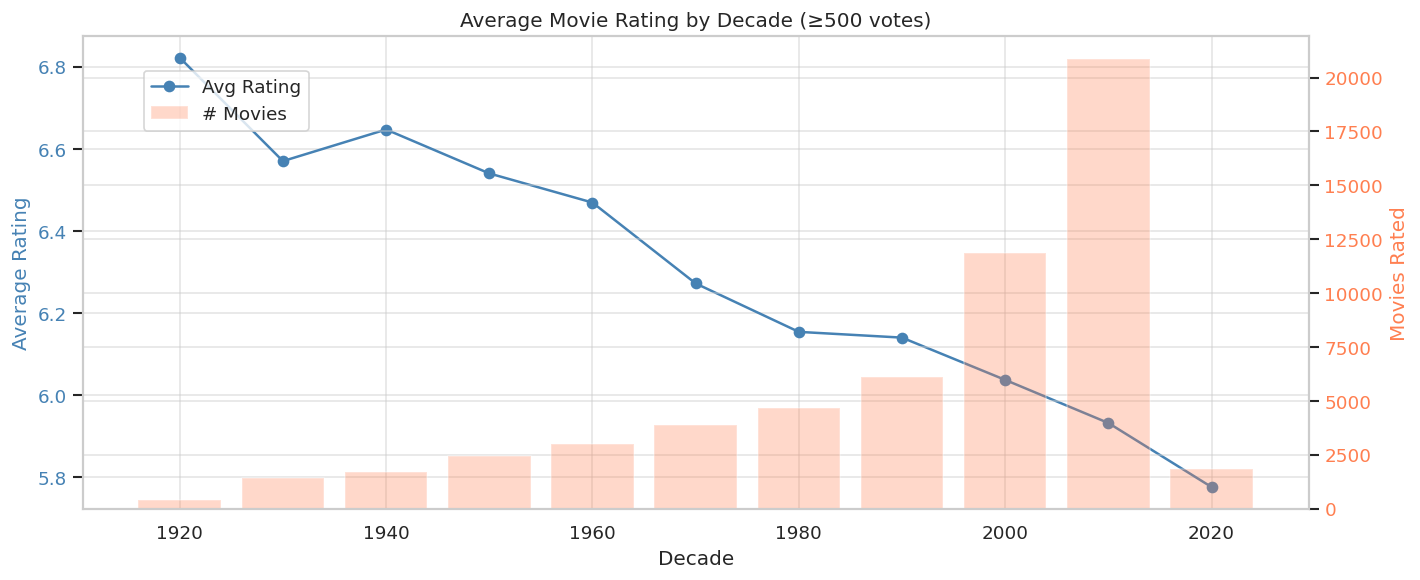

,decade,avg_rating,n
0,1920,6.822,406
1,1930,6.570,1401
2,1940,6.647,1705
3,1950,6.540,2436
4,1960,6.469,3005
5,1970,6.272,3859
6,1980,6.154,4651
7,1990,6.140,6093
8,2000,6.037,11878
9,2010,5.932,20874


In [10]:
decade_rating = q("""
                  SELECT (tb.start_year / 10) * 10                AS decade,
                         ROUND(AVG(r.average_rating)::numeric, 3) AS avg_rating,
                         COUNT(*)                                 AS n
                  FROM title_basics tb
                           JOIN title_ratings r ON tb.tconst = r.tconst
                  WHERE tb.title_type = 'movie'
                    AND tb.start_year BETWEEN 1920 AND 2020
                    AND r.num_votes >= 500
                  GROUP BY decade
                  ORDER BY decade
                  """)

fig, ax1 = plt.subplots(figsize=(12, 5))
color1, color2 = "steelblue", "coral"
ax1.plot(decade_rating["decade"], decade_rating["avg_rating"], marker="o", color=color1, label="Avg Rating")
ax1.set_xlabel("Decade")
ax1.set_ylabel("Average Rating", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.bar(decade_rating["decade"], decade_rating["n"], width=8, alpha=0.3, color=color2, label="# Movies")
ax2.set_ylabel("Movies Rated", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax1.set_title("Average Movie Rating by Decade (≥500 votes)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()
decade_rating

## 11. Runtime Distribution (Movies)

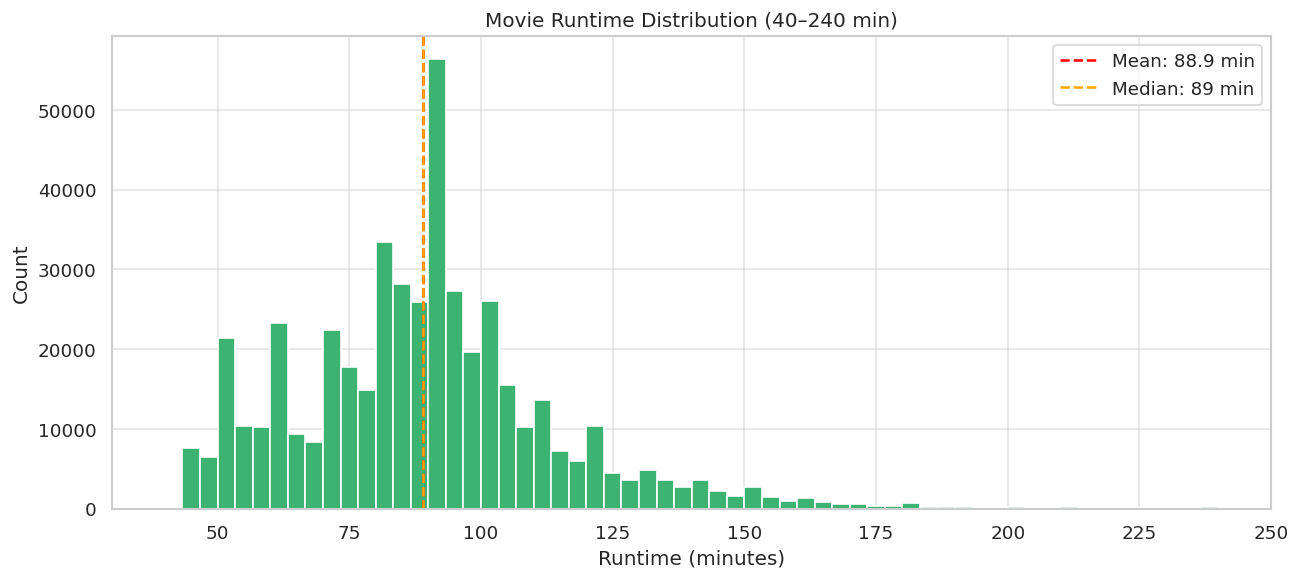

count    469636.0
mean         88.9
std          24.9
min          40.0
25%          73.0
50%          89.0
75%         100.0
max         240.0
Name: runtime_minutes, dtype: float64

In [11]:
runtime = q("""
            SELECT runtime_minutes
            FROM title_basics
            WHERE title_type = 'movie'
              AND runtime_minutes BETWEEN 40 AND 240
            """)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(runtime["runtime_minutes"], bins=60, edgecolor="white", color="mediumseagreen")
ax.axvline(runtime["runtime_minutes"].mean(), color="red", linestyle="--",
           label=f"Mean: {runtime['runtime_minutes'].mean():.1f} min")
ax.axvline(runtime["runtime_minutes"].median(), color="orange", linestyle="--",
           label=f"Median: {runtime['runtime_minutes'].median():.0f} min")
ax.set_title("Movie Runtime Distribution (40–240 min)")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

runtime["runtime_minutes"].describe().round(1)

## 12. Top Directors by Weighted Average Rating

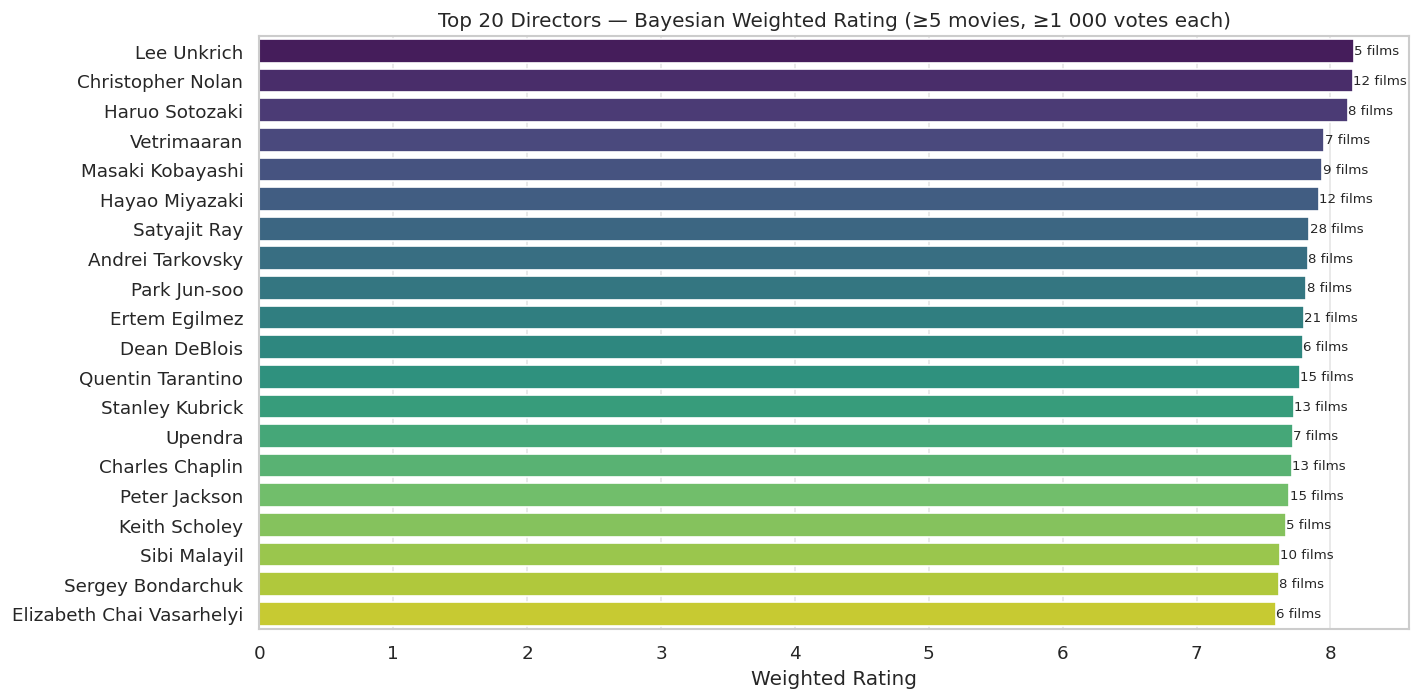

,director,movies,avg_rating,weighted_rating
0,Lee Unkrich,5,8.18,8.176
1,Christopher Nolan,12,8.17,8.166
2,Haruo Sotozaki,8,8.20,8.128
3,Vetrimaaran,7,8.10,7.954
4,Masaki Kobayashi,9,8.04,7.940
5,Hayao Miyazaki,12,7.92,7.912
6,Satyajit Ray,28,7.94,7.843
7,Andrei Tarkovsky,8,7.86,7.830
8,Park Jun-soo,8,8.35,7.820
9,Ertem Egilmez,21,7.86,7.802


In [13]:
# Weighted rating = (v/(v+m)) * R + (m/(v+m)) * C  (Bayesian average, m = 10000)
top_directors = q("""
                  WITH director_films AS (SELECT nb.primary_name AS director,
                                                 r.average_rating,
                                                 r.num_votes
                                          FROM title_crew tc
                                                   JOIN title_basics tb ON tc.tconst = tb.tconst
                                                   JOIN title_ratings r ON tc.tconst = r.tconst
                                                   JOIN name_basics nb ON nb.nconst = ANY (tc.directors)
                                          WHERE tb.title_type = 'movie'
                                            AND r.num_votes >= 1000),
                       global_avg AS (SELECT AVG(average_rating) AS C
                                      FROM director_films)
                  SELECT df.director,
                         COUNT(*)                                          AS movies,
                         ROUND(CAST(AVG(df.average_rating) as numeric), 2) AS avg_rating,
                         ROUND(CAST(
                                       ((SUM(df.num_votes) / (SUM(df.num_votes) + 10000.0)) * AVG(df.average_rating)
                                           + (10000.0 / (SUM(df.num_votes) + 10000.0)) * MAX(ga.C)) as numeric)
                             , 3)                                          AS weighted_rating
                  FROM director_films df,
                       global_avg ga
                  GROUP BY df.director
                  HAVING COUNT(*) >= 5
                  ORDER BY weighted_rating DESC
                  LIMIT 20 """)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_directors, x="weighted_rating", y="director", ax=ax,
            hue="director", legend=False, palette="viridis")
ax.set_title("Top 20 Directors — Bayesian Weighted Rating (≥5 movies, ≥1 000 votes each)")
ax.set_xlabel("Weighted Rating")
ax.set_ylabel("")
for i, (_, row) in enumerate(top_directors.iterrows()):
    ax.text(row["weighted_rating"] + 0.002, i, f"{row['movies']} films", va="center", fontsize=8)
plt.tight_layout()
plt.show()
top_directors

## 13. Most Prolific Actors / Actresses

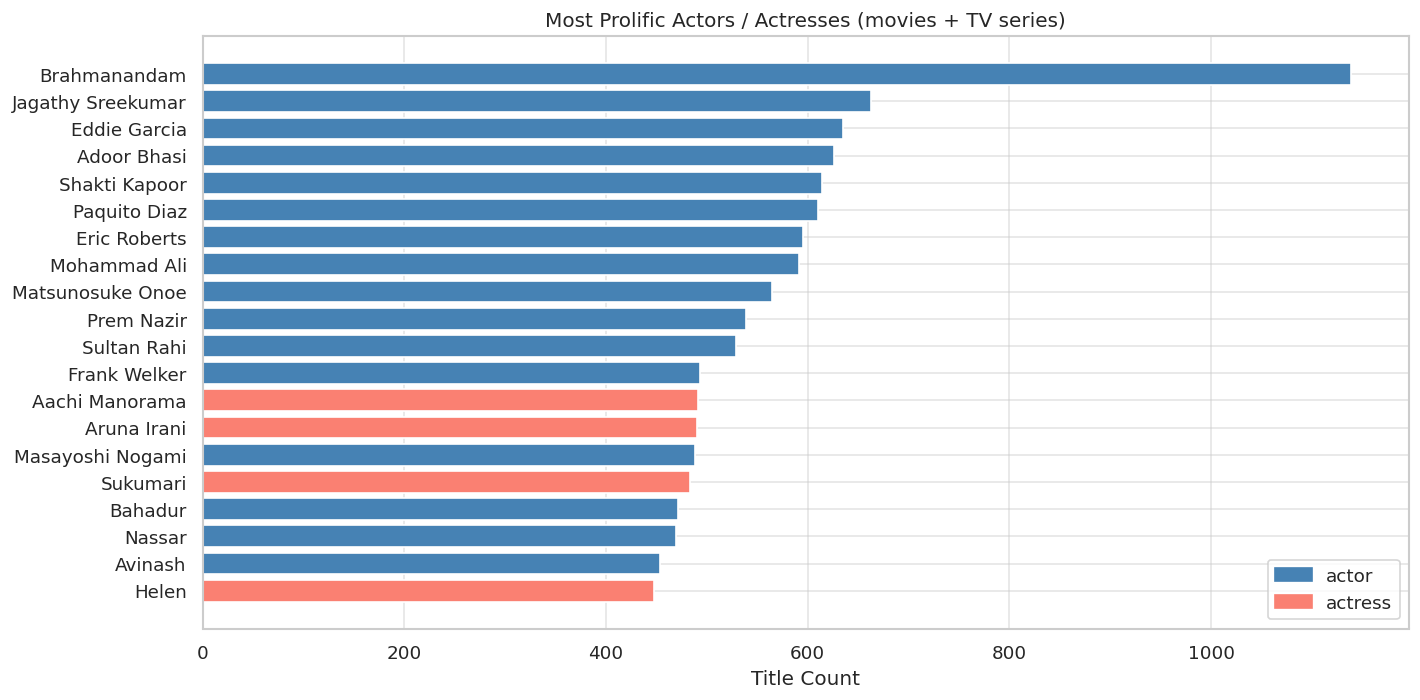

,primary_name,category,title_count
0,Brahmanandam,actor,1139
1,Jagathy Sreekumar,actor,663
2,Eddie Garcia,actor,635
3,Adoor Bhasi,actor,626
4,Shakti Kapoor,actor,614
5,Paquito Diaz,actor,610
6,Eric Roberts,actor,595
7,Mohammad Ali,actor,591
8,Matsunosuke Onoe,actor,565
9,Prem Nazir,actor,539


In [14]:
prolific = q("""
             SELECT nb.primary_name, tp.category, COUNT(*) AS title_count
             FROM title_principals tp
                      JOIN name_basics nb ON tp.nconst = nb.nconst
                      JOIN title_basics tb ON tp.tconst = tb.tconst
             WHERE tp.category IN ('actor', 'actress')
               AND tb.title_type IN ('movie', 'tvSeries')
             GROUP BY nb.primary_name, tp.category
             ORDER BY title_count DESC
             LIMIT 20
             """)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["steelblue" if c == "actor" else "salmon" for c in prolific["category"]]
ax.barh(prolific["primary_name"], prolific["title_count"], color=colors)
ax.invert_yaxis()
ax.set_title("Most Prolific Actors / Actresses (movies + TV series)")
ax.set_xlabel("Title Count")
# legend
from matplotlib.patches import Patch

ax.legend(handles=[Patch(color="steelblue", label="actor"), Patch(color="salmon", label="actress")])
plt.tight_layout()
plt.show()
prolific

## 14. Country Coverage (Title AKAs)

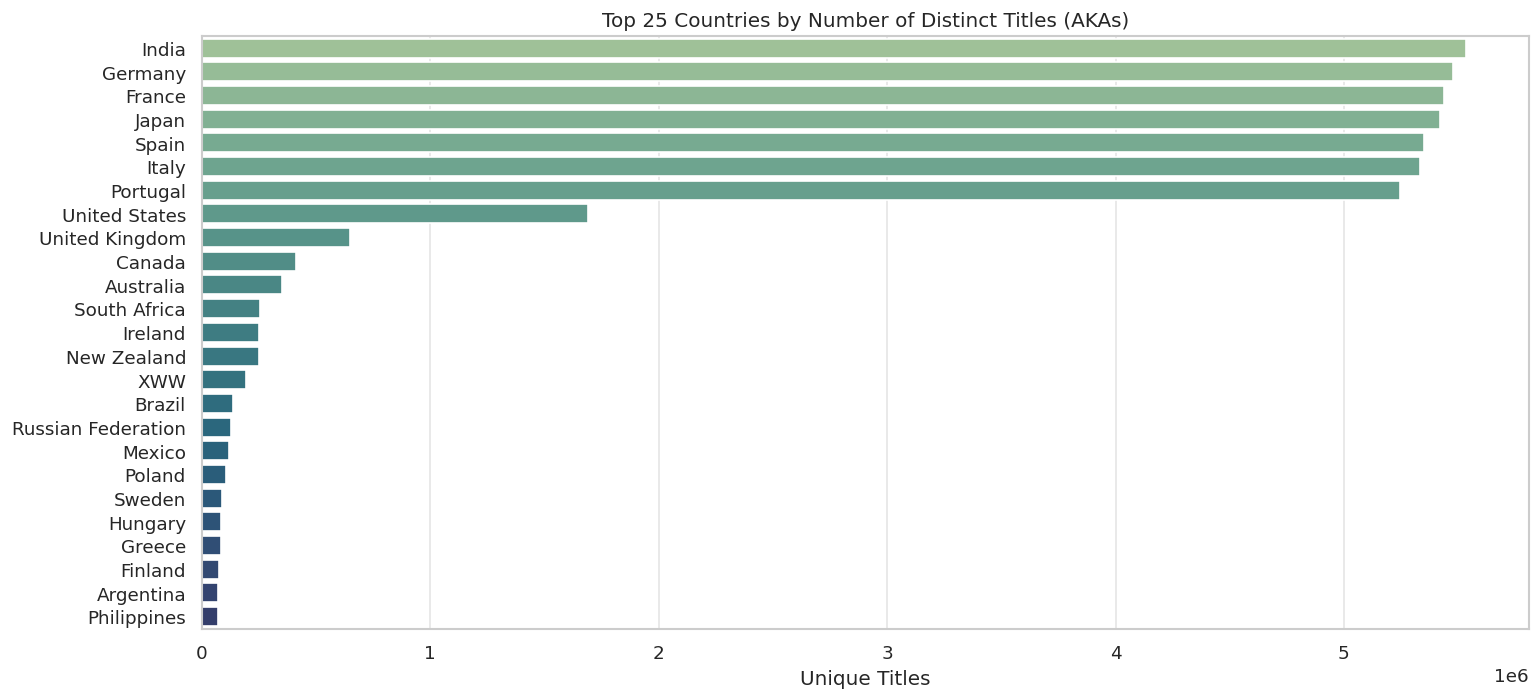

,country_name,unique_titles
0,India,5532699
1,Germany,5477773
2,France,5437213
3,Japan,5421050
4,Spain,5351800
5,Italy,5331747
6,Portugal,5244777
7,United States,1691130
8,United Kingdom,648353
9,Canada,414289


In [15]:
country_coverage = q("""
                     SELECT country_name, COUNT(DISTINCT title_id) AS unique_titles
                     FROM title_akas
                     WHERE country_name IS NOT NULL
                     GROUP BY country_name
                     ORDER BY unique_titles DESC
                     LIMIT 25
                     """)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=country_coverage, x="unique_titles", y="country_name",
            ax=ax, hue="country_name", legend=False, palette="crest")
ax.set_title("Top 25 Countries by Number of Distinct Titles (AKAs)")
ax.set_xlabel("Unique Titles")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
country_coverage.head(10)

## 15. TV Series: Episodes per Season (top shows)

In [17]:
# Find top-rated long-running series and their episode counts per season
top_series = q("""
               SELECT tb.primary_title, tb.tconst, r.average_rating, r.num_votes
               FROM title_basics tb
                        JOIN title_ratings r ON tb.tconst = r.tconst
               WHERE tb.title_type = 'tvSeries'
                 AND r.num_votes >= 50000
               ORDER BY r.average_rating DESC
               LIMIT 15
               """)

top_series[["primary_title", "average_rating", "num_votes"]]

,primary_title,average_rating,num_votes
0,Breaking Bad,9.5,2614264
1,Avatar: The Last Airbender,9.3,441641
2,The Wire,9.3,431289
3,Our Planet,9.2,62857
4,Game of Thrones,9.2,2614077
5,Sapne Vs Everyone,9.2,79509
6,The Sopranos,9.2,579306
7,The Chosen,9.1,70083
8,TVF Pitchers,9.1,79677
9,Aspirants,9.1,318845


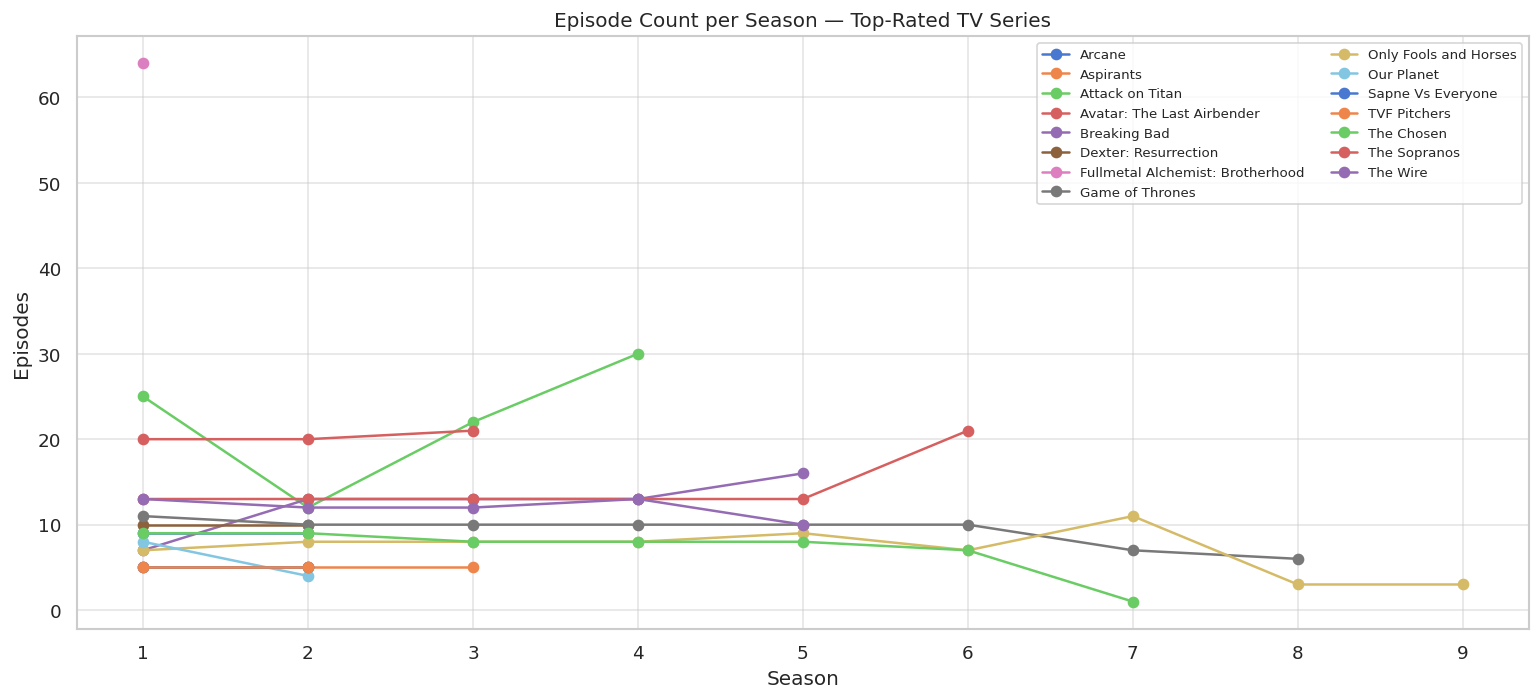

In [18]:
# Episode count by season for each top series
tconsts = tuple(top_series["tconst"].tolist())
titles_map = dict(zip(top_series["tconst"], top_series["primary_title"]))

eps = q("""
        SELECT te.parent_tconst, te.season_number, COUNT(*) AS episode_count
        FROM title_episode te
        WHERE te.parent_tconst IN :tconsts
          AND te.season_number IS NOT NULL
        GROUP BY te.parent_tconst, te.season_number
        ORDER BY te.parent_tconst, te.season_number
        """, tconsts=tconsts)

eps["show"] = eps["parent_tconst"].map(titles_map)

fig, ax = plt.subplots(figsize=(13, 6))
for show, grp in eps.groupby("show"):
    ax.plot(grp["season_number"], grp["episode_count"], marker="o", label=show)
ax.set_title("Episode Count per Season — Top-Rated TV Series")
ax.set_xlabel("Season")
ax.set_ylabel("Episodes")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 16. Ad-hoc Query Cell

In [19]:
sql = """
      SELECT *
      FROM title_basics
      LIMIT 5 \
      """
q(sql)

,tconst,title_type,primary_title,original_title,is_adult,start_year,end_year,runtime_minutes,genres
0,tt14101988,tvEpisode,Episode #3.2,Episode #3.2,False,1975,None,NaN,[Game-Show]
1,tt1410199,movie,Almaz Black Box,Almaz Black Box,False,2007,None,90.0,"[Horror, Sci-Fi]"
2,tt14101990,tvEpisode,Episode #3.4,Episode #3.4,False,1975,None,NaN,[Game-Show]
3,tt14101992,tvEpisode,Episode #3.6,Episode #3.6,False,1975,None,NaN,[Game-Show]
4,tt14101994,tvEpisode,Episode #3.5,Episode #3.5,False,1975,None,NaN,[Game-Show]
